In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchsummary import summary
from torch.optim.lr_scheduler import CosineAnnealingLR
from collections import Counter
import time
from sklearn.model_selection import train_test_split

In [37]:
# Setting for the the trianing 
tr_percentage = 0.1# train on provided percetage of data from the entire dataset
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: [{device}]")
print(f'Your are using {tr_percentage*100}% of your dataset')

Using device: [cuda]
Your are using 10.0% of your dataset


In [38]:
# Prepare the dataset directories 
# data_path = "food-classification/ifood-2019-fgvc6"
data_path = "/kaggle/input/datasets/hjhgkyo/food-dataset-ifood2019fgvc"
train_data = os.path.join(data_path, 'train_set/train_set')
test_data = os.path.join(data_path, 'val_set/val_set')

train_imgs = os.listdir(train_data) # get all training images files
test_imgs = os.listdir(test_data) # get all training images files
print(f'There are {len(train_imgs)} training and {len(test_imgs)} testing images')

There are 118475 training and 11994 testing images


In [39]:
# read the labels 
pdf = pd.read_csv(os.path.join(data_path, 'train_labels.csv'))
t_pdf = pd.read_csv(os.path.join(data_path, 'val_labels.csv'))
print(f'Ther are {pdf.isna().sum().sum()} images without labels')
pdf.count()

Ther are 0 images without labels


img_name    118475
label       118475
dtype: int64

In [40]:
# read the classes value
data_classes = pd.read_csv(os.path.join(data_path, 'class_list.txt'), sep=' ') 
data_classes.columns = ['id', 'name']
NUM_CLASSES = len(data_classes)+1
# plot the all class distributions 
all_classes = pdf['label']

# Stratified sampling to get xx% from each class
# trainable_pdf = pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)
trainable_pdf = (
    pdf.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(
        max(2, int(len(x) * tr_percentage)),
        random_state=42
    ).assign(label=x.name), include_groups=False)
)

# test_pdf = t_pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)
test_pdf = (
    t_pdf.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(
        max(2, int(len(x) * tr_percentage)),
        random_state=42
    ).assign(label=x.name), include_groups=False)
)

print(f'There are {NUM_CLASSES} classes')
print(f'There are {len(trainable_pdf)} images for training and validation')
data_classes.head(5), NUM_CLASSES

There are 251 classes
There are 11732 images for training and validation


(   id         name
 0   1      beignet
 1   2      cruller
 2   3  cockle_food
 3   4       samosa
 4   5     tiramisu,
 251)

In [ ]:
pdf.head(5)

In [ ]:
trainable_pdf.head(5)

In [ ]:
test_pdf.head(5)

In [41]:
# plot the class distribution
def plot_class_distributions(num_labels, percentage = 100):
    """
    This method will plot the labels distribution passed in the histogram format
    """
    counts = Counter(num_labels)
    min_class = min(counts, key=counts.get)
    max_class = max(counts, key=counts.get)

    print(f"""
        Min class: {min_class}  ––> {counts[min_class]} images
        Max class: {max_class} ––> {counts[max_class]} images 
    """)

    plt.figure(figsize=(12, 5))
    plt.hist(num_labels, bins=NUM_CLASSES, color='skyblue', edgecolor='black', alpha=0.8)
    plt.title(f"""
        Distribution of {percentage}% Labels
        Min class: {min_class}  ––> {counts[min_class]} images
        Max class: {max_class} ––> {counts[max_class]} images 
    """)
    plt.xlabel('Label Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [7]:
# 162: 34,
minimum_class_val = pdf[pdf['label']==162]
print(f'there are {len(minimum_class_val)} classes') 

there are 34 classes


In [ ]:

img = Image.open(os.path.join(data_path, 'train_set/train_set', 'train_039693.jpg'))
img




        Min class: 162  ––> 34 images
        Max class: 218 ––> 656 images 
    


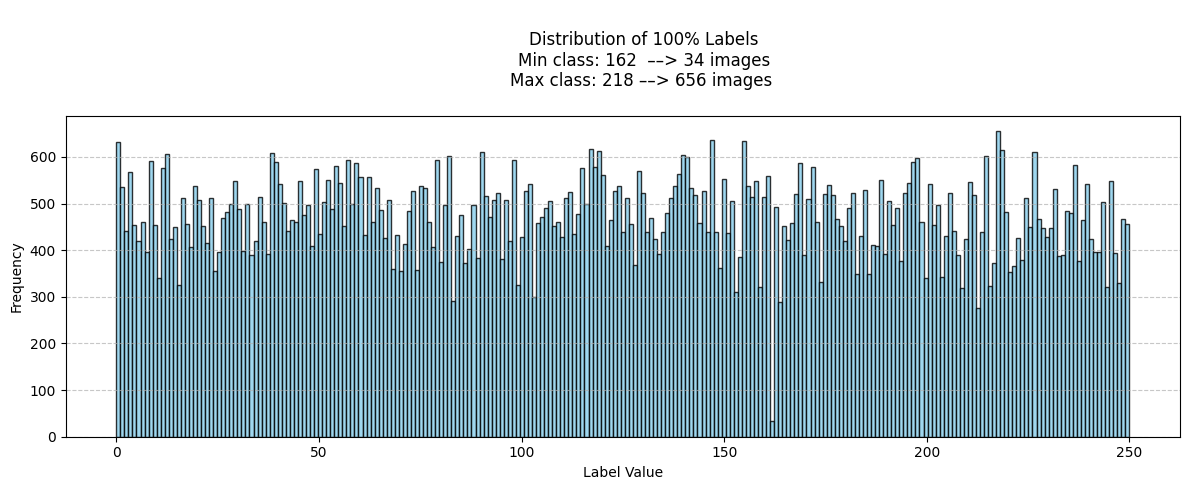

In [42]:
# plot all class distributions 
plot_class_distributions(all_classes)


        Min class: 162  ––> 3 images
        Max class: 218 ––> 65 images 
    


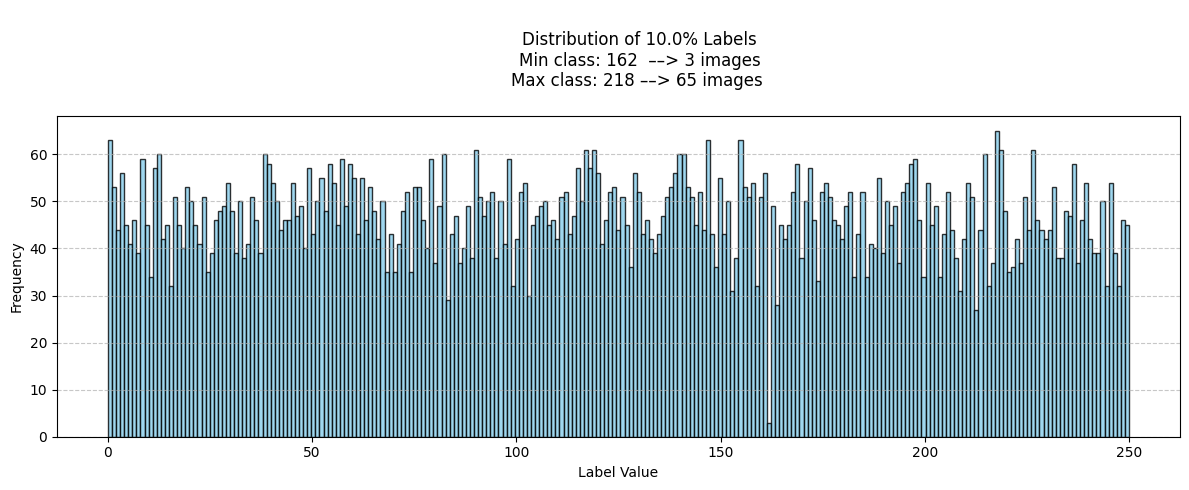

In [43]:
# plot the sampled classes distribution
plot_class_distributions(trainable_pdf['label'], tr_percentage*100)
# Counter(trainable_pdf['label'])

In [ ]:
plt.figure(figsize=(12, 4))

for i in range(16): 
    plt.subplot(2, 8, i + 1)
    
    rand_idx = np.random.randint(len(trainable_pdf))
    rand_pdf = trainable_pdf[rand_idx-1:rand_idx]
    img_name = rand_pdf['img_name'].values[0]
    label = rand_pdf['label'].values[0]
    
    img = Image.open(os.path.join(data_path, 'train_set/train_set', img_name))
    
    title_text = data_classes.iloc[label-1:label]['name'].values[0]
    plt.title(title_text, fontsize=8)
    
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Get the Mean and Std of the training dataset 
# This might take arround 8.5 minutes since I am calculating over the entire dataset
pixel_sum = np.zeros(3) # For RGB sum
pixel_sq_sum = np.zeros(3) 
total_pixels = 0

# this the final values after executing the loop 
# glb_mean = [162.75951001, 138.58583393, 113.06651858]
# glb_std = [70.29061983, 74.10972917, 80.80873226]

# Un comment this if you want to recalculate
# for img_name in train_imgs: 
#     # open image and convert to array format
#     img = np.array(Image.open(os.path.join(data_path, 'train_set', img_name))).astype(np.float32)

#     num_pixels = img.shape[0]*img.shape[1] # get the number of pixels of height and width
#     total_pixels += num_pixels # count the pixels 

#     # Sum pixels per chanel 
#     pixel_sum += np.sum(img, axis=(0, 1))
#     pixel_sq_sum += np.sum(img ** 2, axis=(0, 1))

# # final calucation 
# glb_mean = pixel_sum / total_pixels
# glb_var = (pixel_sq_sum / total_pixels) - (glb_mean ** 2)
# glb_std = np.sqrt(glb_var)
# print(glb_var)
# print("Dataset Mean (R, G, B):", glb_mean)
# print("Dataset Std  (R, G, B):", glb_std)

In [45]:
glb_mean = [0.485, 0.456, 0.406]
glb_std = [0.229, 0.224, 0.225]


In [46]:
class RotationDataset(Dataset):
    def __init__(self, df, dir="train_set/train_set", transform=None):
        self.df = df
        self.dir = dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        file = self.df.iloc[idx].values
        img_name = file[0]
        img = Image.open(os.path.join(data_path, self.dir, img_name))
        if self.transform:
            img = self.transform(img)
        # rotate and get lables
        rot_label = torch.randint(0, 4, (1,)).item()
        img = torch.rot90(img, rot_label, dims=[1, 2])
        return img, rot_label

In [47]:
# Create training and validation transform pipeline 
SIZE = 160
train_transform = transforms.Compose([
    transforms.Resize(size=(SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(), 
    
    transforms.RandomCrop(160, padding=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])
val_transform = transforms.Compose([  
    transforms.Resize(size=(SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])

In [48]:
# split the train dataset in training (75%), validation (25%)
training_df, validation_df = train_test_split(
    trainable_pdf,
    test_size=0.25,
    stratify=trainable_pdf['label'],
    random_state=42
)
print(f'{len(training_df)} images for training \n{len(validation_df)} images for validation \n{len(test_pdf)} images for testinng.')

8799 images for training 
2933 images for validation 
1094 images for testinng.


In [49]:
# Get the training, Validation and testing datas
train_data = RotationDataset(training_df, 'train_set/train_set', train_transform)
val_data = RotationDataset(validation_df, 'train_set/train_set', val_transform)
test_data = RotationDataset(test_pdf, 'val_set/val_set', val_transform)
len(train_data), len(val_data), len(test_data)

(8799, 2933, 1094)

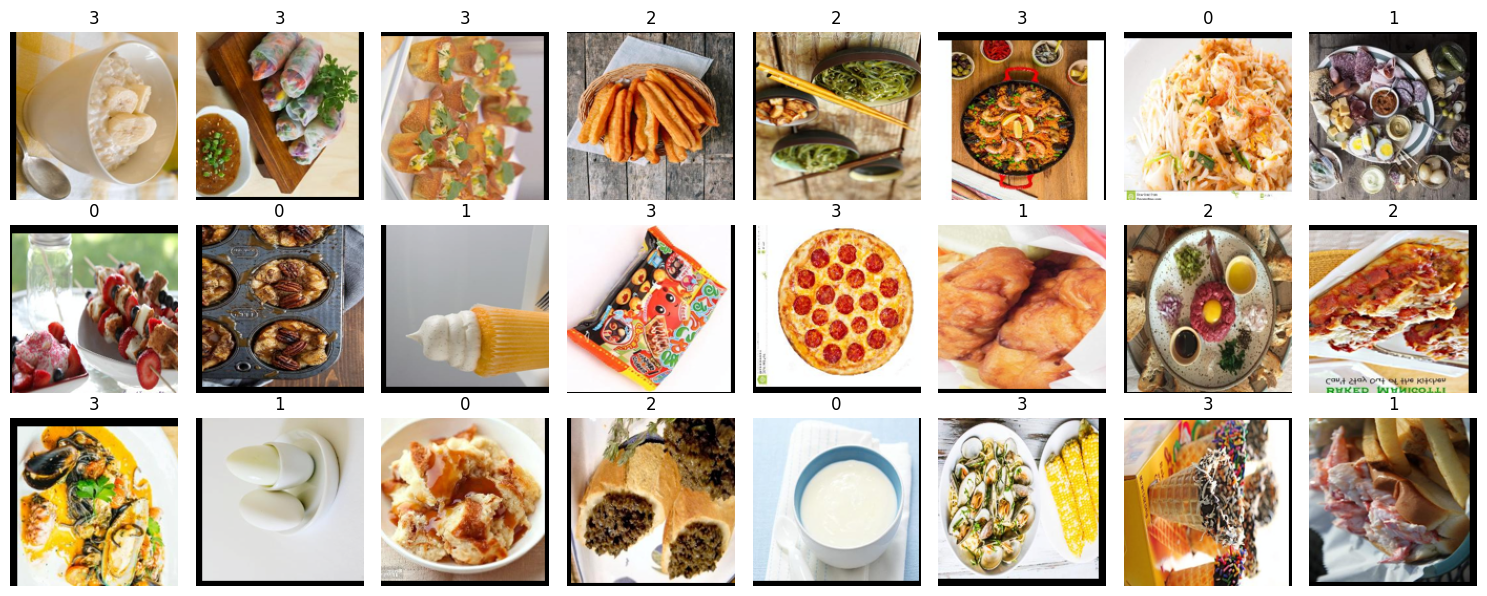

In [50]:
# plot some random rotated images 
plt.figure(figsize=(15, 6))

for i in range(24): 
    plt.subplot(3, 8, i + 1)
    
    rand_idx = np.random.randint(len(train_data))
    img, label = train_data.__getitem__(rand_idx)
    img = img.permute(1, 2, 0).numpy()

    #  denormalize
    img = glb_std * img + glb_mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f'{label}')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [52]:
# Add data loader 
BATCH_SIZE = 32
PIN_MEMORY = True if device == 'cuda' or device == 'mps' else False
NUM_WORKERS = 0
train_loader = DataLoader(train_data,
                          batch_size=BATCH_SIZE,
                          shuffle=True, 
                          # sampler=sampler,
                          drop_last=True, 
                          pin_memory=PIN_MEMORY,
                          num_workers=NUM_WORKERS)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
print(f"There are \n {len(train_loader)} training batches \n {len(val_loader)} validation batches \n {len(test_loader)} testing batches")


There are 
 274 training batches 
 92 validation batches 
 35 testing batches


## Self-supervised learning 

```
        Food Images (ignore labels)
                ↓
        SimCLR-style training
                ↓
        CNN Encoder learns features
                ↓
        Remove projection head
                ↓
        Extract features
                ↓
        Train SVM / Logistic Regression / CNN Classifier
                ↓
        251 Food Classes
```

In [54]:
# inspired by vgg-16 
# https://arxiv.org/abs/1409.1556
"""
    The network architecture inspired by VGG-16 with following update
    1. Add Batch Normalization after each Convolution layer to have a faster convergance and more stable gradient 
    2. Add Dropout layer before classification layer to raiseeduces co-adaptation of neurons
    3. only 4 blocks while VGG-16 have 5 blocks
"""

class Net(nn.Module):
    
    def __init__(self):
        super().__init__() 
        self.conv_b1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_b2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_b3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_b4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        ) 

    def forward(self, x):   
        x = self.conv_b1(x)
        x = self.conv_b2(x)
        x = self.conv_b3(x)
        x = self.conv_b4(x)
        return x
net = Net().to(device)
# log the total number of parameter
model_parameters = filter(lambda p: p.requires_grad, net.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(f'The model has {params} trainable parameters')

The model has 7640640 trainable parameters


In [23]:
summary(net, input_size=(3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           1,792
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          36,928
       BatchNorm2d-5           [-1, 64, 64, 64]             128
              ReLU-6           [-1, 64, 64, 64]               0
         MaxPool2d-7           [-1, 64, 32, 32]               0
            Conv2d-8          [-1, 128, 32, 32]          73,856
       BatchNorm2d-9          [-1, 128, 32, 32]             256
             ReLU-10          [-1, 128, 32, 32]               0
           Conv2d-11          [-1, 128, 32, 32]         147,584
      BatchNorm2d-12          [-1, 128, 32, 32]             256
             ReLU-13          [-1, 128, 32, 32]               0
        MaxPool2d-14          [-1, 128,

In [55]:
class RotationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Net()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(512, 4)
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.head(x)
        return x
rotationNet = RotationNet().to(device)
summary(rotationNet, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]          36,928
       BatchNorm2d-5         [-1, 64, 224, 224]             128
              ReLU-6         [-1, 64, 224, 224]               0
         MaxPool2d-7         [-1, 64, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]          73,856
       BatchNorm2d-9        [-1, 128, 112, 112]             256
             ReLU-10        [-1, 128, 112, 112]               0
           Conv2d-11        [-1, 128, 112, 112]         147,584
      BatchNorm2d-12        [-1, 128, 112, 112]             256
             ReLU-13        [-1, 128, 112, 112]               0
        MaxPool2d-14          [-1, 128,

In [56]:
# Setup the model compiler
EPOCHS = 50
optimizer = torch.optim.AdamW(rotationNet.parameters(), lr=1e-3, weight_decay=1e-4) 

# loss method 
loss_fun = nn.CrossEntropyLoss()

# per-epoch stepping
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


In [57]:
# Create a training method for non-labeled data
def train_model(model, dataloader, loss_fun, optimizer):
  training_loss, total, correct = 0, 0, 0 
  model.train()
  for batch, (X, y), in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    if y.ndim == 2:
        y = y.squeeze(1)
    y = y.long()
    optimizer.zero_grad() # reset the gradient
    y_pred = model(X) # (B, C, H, W)
    loss = loss_fun(y_pred, y) # calculate the loss

    loss.backward() # comput the gradient
    optimizer.step() # update the weight
    training_loss += loss.item()
    # Calculate the training accuracy
    preds = torch.argmax(y_pred, dim=1)
    correct += (preds == y).sum().item()
    total += y.size(0) 
    
    if (batch+1 == len(dataloader)):
      print(f'Batch {batch+1}/{len(dataloader)} | Loss: {loss.item():.4f}')
  training_acc = correct / total 
  return training_loss/len(dataloader), training_acc, 


In [58]:
# Create a validation method
def validate_model(model, dataloader, loss_fun, epoch):
  model.eval()
  val_loss, correct, total = 0, 0, 0
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      if y.ndim == 2:
        y = y.squeeze(1)
      y = y.long()
      y_pred = model(X)
      loss = loss_fun(y_pred, y)
      val_loss += loss.item() 
      preds = torch.argmax(y_pred, dim=1)
      # accuracy in pixel level
      correct += (preds == y).sum().item()
      total += y.size(0)

    val_acc = correct/total
  return val_loss/len(dataloader), val_acc

In [59]:
output_path = "/kaggle/working"

In [60]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [], 
    "lr": [], 
}
best_val_loss = float('inf')

patience, epochs_no_improve = 10, 0
best_val_acc = 0
start_train_time = time.time()
for i in range(EPOCHS):
    print(f'Epoch {i+1}:')
    tr_loss, tr_acc = train_model(rotationNet, train_loader, loss_fun, optimizer)
    history['train_acc'].append(tr_acc)
    history['train_loss'].append(tr_loss) 
    scheduler.step()

    val_loss, val_acc = validate_model(rotationNet, val_loader, loss_fun, i+1)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss) 
    history['lr'].append(optimizer.param_groups[-1]['lr'])
    

    print(f"""
    tr loss [{tr_loss:.4f}] | val loss [{val_loss:.4f}]
    tr acc [{tr_acc:.4f}] | val acc [{val_acc:.4f}] | lr [{optimizer.param_groups[-1]['lr']:.6f}]
    """) 

    # Save only weights of the best model 
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(rotationNet.state_dict(), f'{output_path}/best_model_weights.pth')
        print("Best model saved!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {i+1}")
            break
torch.save(rotationNet.state_dict(), f'{output_path}/last_model.pth')
print(f'Last model saved correctly')
end_train_time = time.time()
print(f'End training after {(end_train_time - start_train_time)/60:.4f} minutes')

Epoch 1:
Batch 274/274 | Loss: 1.4208

    tr loss [1.4095] | val loss [1.3956]
    tr acc [0.2648] | val acc [0.2564] | lr [0.000999]
    
Best model saved!
Epoch 2:
Batch 274/274 | Loss: 1.3661

    tr loss [1.3903] | val loss [1.3919]
    tr acc [0.2702] | val acc [0.3154] | lr [0.000996]
    
Best model saved!
Epoch 3:
Batch 274/274 | Loss: 1.4102

    tr loss [1.3697] | val loss [1.4363]
    tr acc [0.3051] | val acc [0.3273] | lr [0.000991]
    
Best model saved!
Epoch 4:
Batch 274/274 | Loss: 1.4655

    tr loss [1.3545] | val loss [1.3922]
    tr acc [0.3289] | val acc [0.3287] | lr [0.000984]
    
Best model saved!
Epoch 5:
Batch 274/274 | Loss: 1.1268

    tr loss [1.3106] | val loss [1.3707]
    tr acc [0.3840] | val acc [0.3559] | lr [0.000976]
    
Best model saved!
Epoch 6:
Batch 274/274 | Loss: 1.3162

    tr loss [1.2738] | val loss [1.2325]
    tr acc [0.4245] | val acc [0.4405] | lr [0.000965]
    
Best model saved!
Epoch 7:
Batch 274/274 | Loss: 1.2791

    tr loss [

<Axes: >

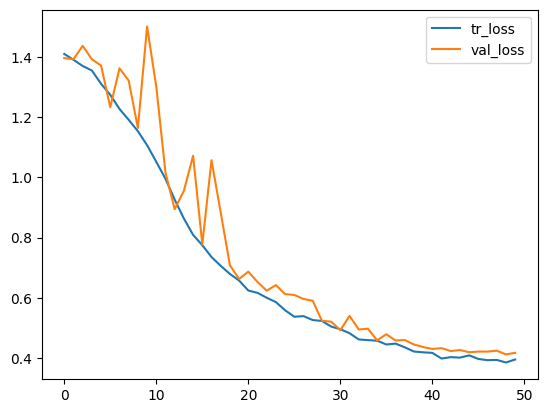

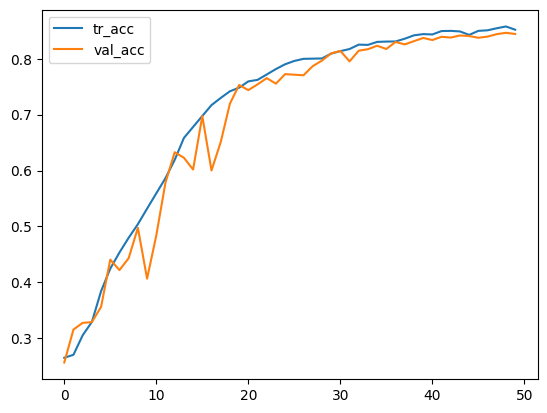

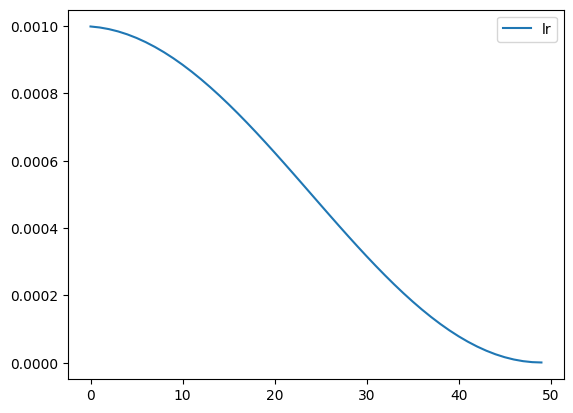

In [63]:
# Plot the learning curve 
pd.DataFrame({'tr_loss': history['train_loss'], 'val_loss': history['val_loss']}).plot()
pd.DataFrame({'tr_acc': history['train_acc'], 'val_acc': history['val_acc']}).plot()
pd.DataFrame({'lr': history['lr']}).plot()

In [146]:
loaded_model = RotationNet().to(device)
loaded_model.load_state_dict(torch.load('/kaggle/working/best_model_weights.pth', weights_only=True))
loaded_model.eval()

RotationNet(
  (encoder): Net(
    (conv_b1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv_b2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_m

In [82]:
# visualize feature maps or deeper layer activations to see how model is learning

layers = {
    "Block 1 (Low-level edges)": loaded_model.encoder.conv_b1,
    "Block 2 (Textures)": loaded_model.encoder.conv_b2,
    "Block 3 (Shapes)": loaded_model.encoder.conv_b3,
    "Block 4 (High-level patterns)": loaded_model.encoder.conv_b4,
}

In [83]:

activations = {}
handles = []
# Create hooks
def get_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

for name, layer in layers.items():
    handles.append(layer.register_forward_hook(get_hook(name))) # register and add to handles

/tmp/ipykernel_58/965106565.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  org_img = np.array(org_img.cpu().permute(1,2,0))


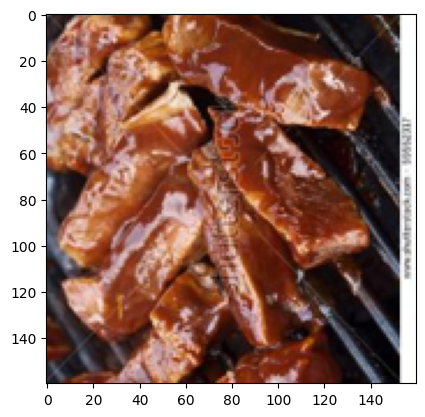

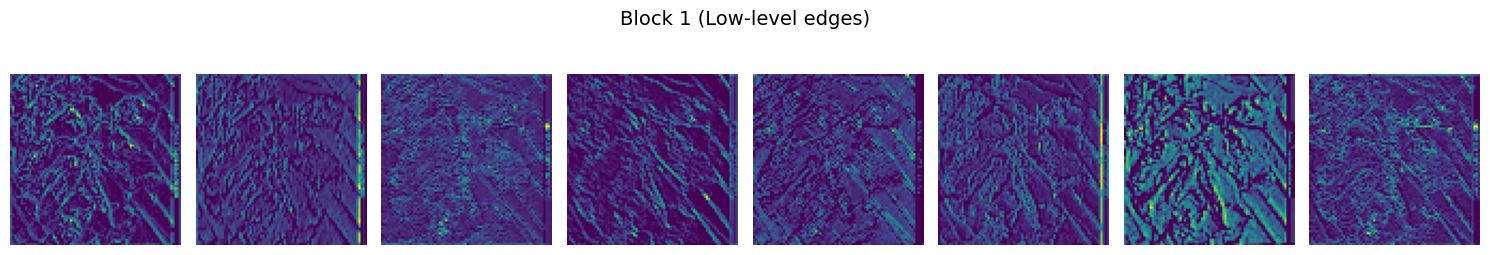

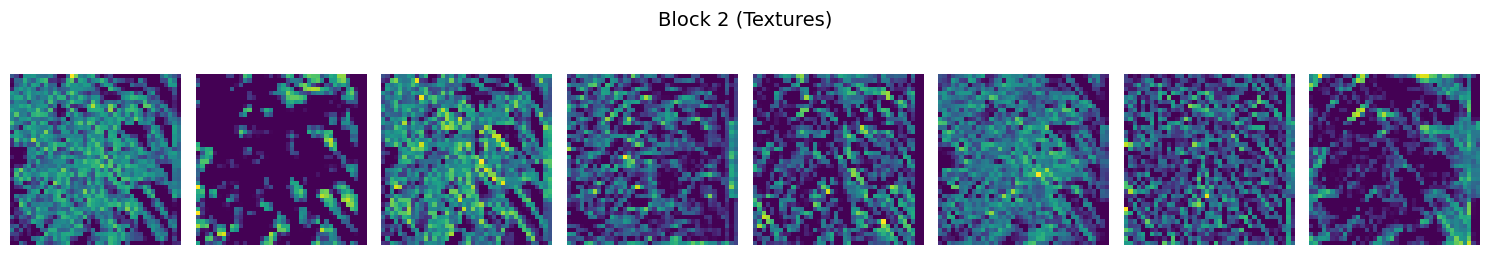

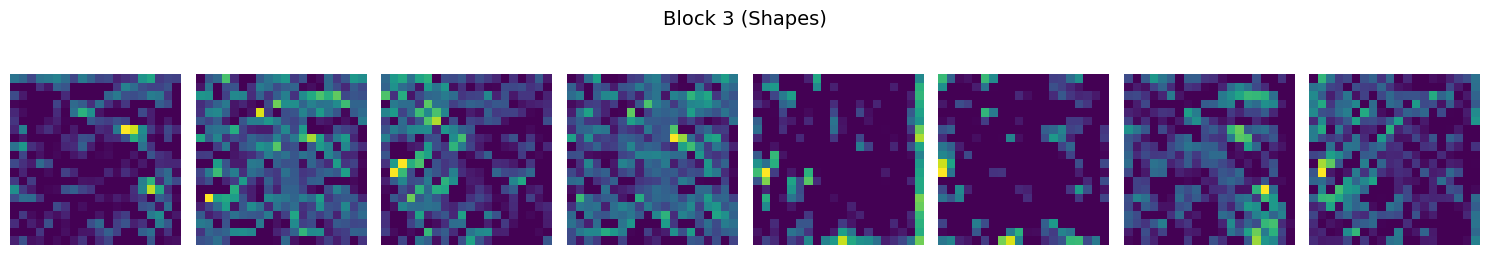

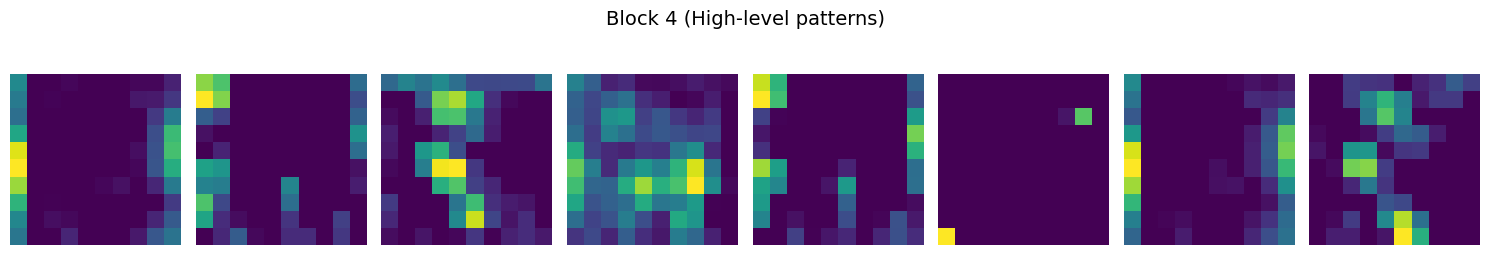

In [100]:
img, label = test_data.__getitem__(np.random.randint(len(test_data)))
org_img = img
org_img = np.array(org_img.cpu().permute(1,2,0))
#  denormalize
org_img = glb_std * org_img + glb_mean
org_img = np.clip(org_img, 0, 1)

plt.imshow(org_img)
plt.show()

img = img.unsqueeze(0).float().to(device)

loaded_model.eval()

with torch.no_grad():
    _ = loaded_model(img)


def plot_layer_features(feat_maps, title, n=8):
    fmap = feat_maps[0]  # [C, H, W]

    plt.figure(figsize=(15, 5))
    plt.suptitle(title, fontsize=14)

    for i in range(n):
        plt.subplot(2, 8, i + 1)
        plt.imshow(fmap[i].cpu())
        plt.axis("off")

    plt.tight_layout()
    plt.show()
for name in layers.keys():
    plot_layer_features(activations[name], name, n=8)



### Extract Features
Remove the rotation head and keep only the encoder.

In [147]:
loaded_encoder = loaded_model.encoder # keep only encoder

In [148]:
# Freeze the encoder 
for p in loaded_encoder.parameters():
    p.requires_grad = False # freeze all 

In [149]:
class FoodClassifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()

        self.encoder = loaded_encoder

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 251)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.head(x)
        return x
food_cls = FoodClassifier(loaded_encoder).to(device)
summary(food_cls, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]          36,928
       BatchNorm2d-5         [-1, 64, 224, 224]             128
              ReLU-6         [-1, 64, 224, 224]               0
         MaxPool2d-7         [-1, 64, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]          73,856
       BatchNorm2d-9        [-1, 128, 112, 112]             256
             ReLU-10        [-1, 128, 112, 112]               0
           Conv2d-11        [-1, 128, 112, 112]         147,584
      BatchNorm2d-12        [-1, 128, 112, 112]             256
             ReLU-13        [-1, 128, 112, 112]               0
        MaxPool2d-14          [-1, 128,

In [150]:
# Setup the model compiler
EPOCHS = 50
optimizer = torch.optim.AdamW(food_cls.parameters(), lr=3e-4, weight_decay=1e-4) 

# loss method 
loss_fun = nn.CrossEntropyLoss()

# per-epoch stepping
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


In [151]:
# load the ground throught dataset and evaluate against the SSL model
class Myclass(Dataset):
    def __init__(self, df, dir='train_set/train_set', transform=None):
        super().__init__()
        self.df = df 
        self.dir = dir # images directory
        self.transform = transform 
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        file = self.df.iloc[idx].values
        img_name = file[0]
        label = file[1]
        img = Image.open(os.path.join(data_path, self.dir, img_name))
        if self.transform:
            img = self.transform(img)
        return img, label

In [152]:
# split the train dataset in training (75%), validation (25%)
training_df, validation_df = train_test_split(
    trainable_pdf,
    test_size=0.25,
    stratify=trainable_pdf['label'],
    random_state=42
)
print(f'{len(training_df)} images for training \n{len(validation_df)} images for validation \n{len(test_pdf)} images for testinng.')

8799 images for training 
2933 images for validation 
1094 images for testinng.


In [153]:
# Get the training, Validation and testing datas
train_data = Myclass(training_df, 'train_set/train_set', train_transform)
val_data = Myclass(validation_df, 'train_set/train_set', val_transform)
test_data = Myclass(test_pdf, 'val_set/val_set', val_transform)
len(train_data), len(val_data), len(test_data)

(8799, 2933, 1094)

In [154]:
# Add data loader 
BATCH_SIZE = 32
PIN_MEMORY = True if device == 'cuda' or device == 'mps' else False
NUM_WORKERS = 0
train_loader = DataLoader(train_data,
                          batch_size=BATCH_SIZE,
                          shuffle=True, 
                          # sampler=sampler,
                          drop_last=True, 
                          pin_memory=PIN_MEMORY,
                          num_workers=NUM_WORKERS)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
print(f"There are \n {len(train_loader)} training batches \n {len(val_loader)} validation batches \n {len(test_loader)} testing batches")


There are 
 274 training batches 
 92 validation batches 
 35 testing batches


In [141]:
# make sure the labels are ranged properly 
labels = []

for _, y in train_loader:
    labels.extend(y.tolist())

print(min(labels), max(labels))
print(len(set(labels)))

0 250
251


In [158]:
# Create a training method for non-labeled data
def train_model(model, dataloader, loss_fun, optimizer):
  training_loss, total, correct = 0, 0, 0 
  model.train()
  model.encoder.eval() # make sure that encoder is not changing  
  for batch, (X, y), in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    if y.ndim == 2:
        y = y.squeeze(1)
    y = y.long()
    optimizer.zero_grad() # reset the gradient
    y_pred = model(X) # (B, C, H, W)
    loss = loss_fun(y_pred, y) # calculate the loss

    loss.backward() # comput the gradient
    optimizer.step() # update the weight
    training_loss += loss.item()
    # Calculate the training accuracy
    preds = torch.argmax(y_pred, dim=1)
    correct += (preds == y).sum().item()
    total += y.size(0) 
    
    if (batch+1 == len(dataloader)):
      print(f'Batch {batch+1}/{len(dataloader)} | Loss: {loss.item():.4f}')
  training_acc = correct / total 
  return training_loss/len(dataloader), training_acc, 


In [159]:
# Create a validation method
def validate_model(model, dataloader, loss_fun, epoch):
  model.eval()
  val_loss, correct, total = 0, 0, 0
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      if y.ndim == 2:
        y = y.squeeze(1)
      y = y.long()
      y_pred = model(X)
      loss = loss_fun(y_pred, y)
      val_loss += loss.item() 
      preds = torch.argmax(y_pred, dim=1)
      correct += (preds == y).sum().item()
      total += y.size(0)

    val_acc = correct/total
  return val_loss/len(dataloader), val_acc

In [160]:
# Check how many trainable parameters we have there shouldn't be encoder
for name, p in food_cls.named_parameters():
    if p.requires_grad:
        print(name)

head.2.weight
head.2.bias
head.5.weight
head.5.bias


In [161]:
output_path = "/kaggle/working"

In [162]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [], 
    "lr": [], 
}
best_val_loss = float('inf')

patience, epochs_no_improve = 10, 0
best_val_acc = 0
start_train_time = time.time()
for i in range(EPOCHS):
    print(f'Epoch {i+1}:')
    tr_loss, tr_acc = train_model(food_cls, train_loader, loss_fun, optimizer)
    history['train_acc'].append(tr_acc)
    history['train_loss'].append(tr_loss) 
    scheduler.step()

    val_loss, val_acc = validate_model(food_cls, val_loader, loss_fun, i+1)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss) 
    history['lr'].append(optimizer.param_groups[-1]['lr'])
    

    print(f"""
    tr loss [{tr_loss:.4f}] | val loss [{val_loss:.4f}]
    tr acc [{tr_acc:.4f}] | val acc [{val_acc:.4f}] | lr [{optimizer.param_groups[-1]['lr']:.6f}]
    """) 

    # Save only weights of the best model 
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(food_cls.state_dict(), f'{output_path}/food_cls_best_model_weights.pth')
        print("Best model saved!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {i+1}")
            break
torch.save(food_cls.state_dict(), f'{output_path}/food_cls_last_model.pth')
print(f'Last model saved correctly')
end_train_time = time.time()
print(f'End training after {(end_train_time - start_train_time)/60:.4f} minutes')

Epoch 1:
Batch 274/274 | Loss: 5.5166

    tr loss [5.5306] | val loss [5.5072]
    tr acc [0.0042] | val acc [0.0065] | lr [0.000300]
    
Best model saved!
Epoch 2:
Batch 274/274 | Loss: 5.5183

    tr loss [5.5028] | val loss [5.4833]
    tr acc [0.0055] | val acc [0.0102] | lr [0.000299]
    
Best model saved!
Epoch 3:
Batch 274/274 | Loss: 5.4210

    tr loss [5.4747] | val loss [5.4644]
    tr acc [0.0092] | val acc [0.0123] | lr [0.000297]
    
Best model saved!
Epoch 4:
Batch 274/274 | Loss: 5.3950

    tr loss [5.4458] | val loss [5.4521]
    tr acc [0.0111] | val acc [0.0109] | lr [0.000295]
    
Epoch 5:
Batch 274/274 | Loss: 5.4622

    tr loss [5.4242] | val loss [5.4453]
    tr acc [0.0111] | val acc [0.0113] | lr [0.000293]
    
Epoch 6:
Batch 274/274 | Loss: 5.4335

    tr loss [5.3985] | val loss [5.4401]
    tr acc [0.0132] | val acc [0.0150] | lr [0.000290]
    
Best model saved!
Epoch 7:
Batch 274/274 | Loss: 5.4206

    tr loss [5.3857] | val loss [5.4322]
    tr a

<Axes: >

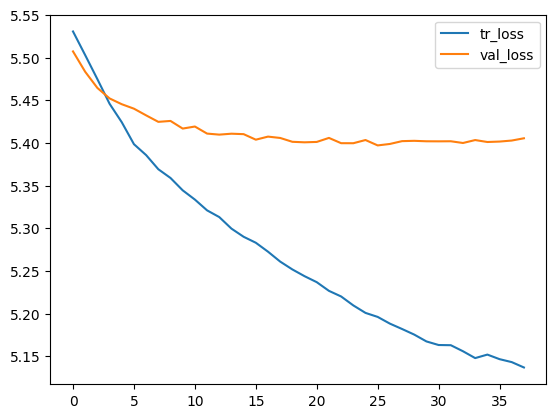

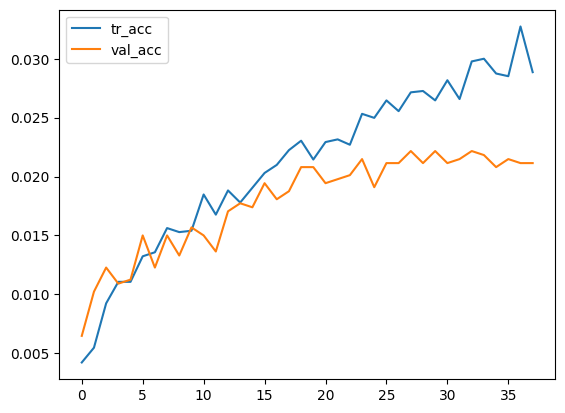

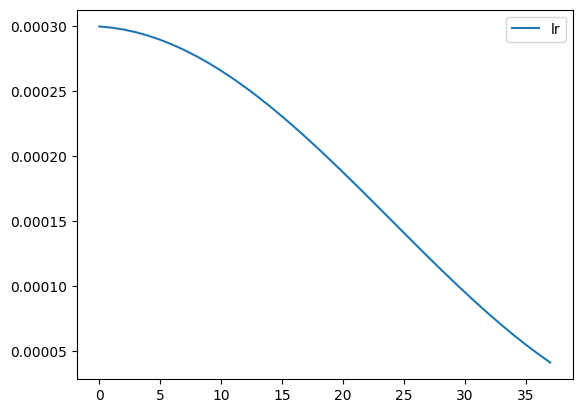

In [163]:
# Plot the learning curve 
pd.DataFrame({'tr_loss': history['train_loss'], 'val_loss': history['val_loss']}).plot()
pd.DataFrame({'tr_acc': history['train_acc'], 'val_acc': history['val_acc']}).plot()
pd.DataFrame({'lr': history['lr']}).plot()

In [164]:
# load the model 
cls_model = FoodClassifier(loaded_encoder).to(device)
cls_model.load_state_dict(torch.load('/kaggle/working/food_cls_last_model.pth', weights_only=True))
cls_model.eval()

FoodClassifier(
  (encoder): Net(
    (conv_b1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv_b2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

Text(0.5, 1.0, 'Gt: beet_salad | Pred: oyster')

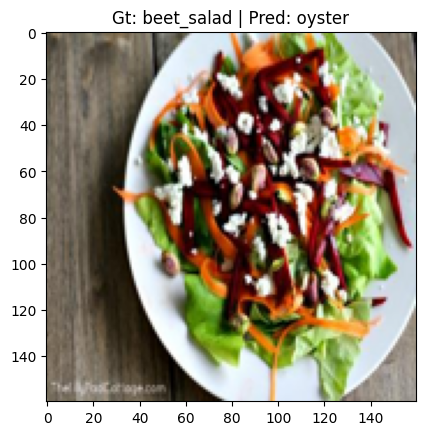

In [173]:
img, label = test_data.__getitem__(np.random.randint(len(test_data)))

img = img.unsqueeze(0).float().to(device)

loaded_model.eval()

cls_model.eval()

with torch.no_grad():
    y_pred = cls_model(img)
pred_label = y_pred.argmax(dim=1).item()
img_np = img.squeeze(0).cpu().permute(1, 2, 0).numpy()
#  denormalize
img_np = glb_std * img_np + glb_mean
img_np = np.clip(img_np, 0, 1)

title_text = data_classes.iloc[label-1:label]['name'].values[0]
pred_text = data_classes.iloc[pred_label-1:pred_label]['name'].values[0]

plt.imshow(img_np)
plt.title(f'Gt: {title_text} | Pred: {pred_text}')